In [2]:
#1 Solving a System of Linear Equations
#import
import numpy as np

In [3]:
#create matrix a 
A = np.array([
    [27, -10, 4, -29],
    [-16, 5, -2, 18],
    [-17, 4, -2, 20],
    [-7, 2, -1, 8]
])

In [4]:
#create vector b 
b = np.array([
    1,
    -1,
    0,
    1
])

In [5]:
#solve the system 
x = np.linalg.solve(A, b)

print("Solution:")
print(x)

Solution:
[10.  3. -9.  7.]


In [6]:
#print all variables 
print(f"x1 = {x[0]}")
print(f"x2 = {x[1]}")
print(f"x3 = {x[2]}")
print(f"x4 = {x[3]}")

x1 = 10.00000000000003
x2 = 3.0000000000000173
x3 = -9.000000000000036
x4 = 7.000000000000018


In [7]:
#2 Visualizing a Linear Transformation
#import libraries
import numpy as np
import matplotlib.pyplot as plt

In [8]:
#create transformation matrix 
A = np.array([
    [np.sqrt(2)/2, -np.sqrt(2)/2],
    [np.sqrt(2)/2,  np.sqrt(2)/2]
])

In [10]:
#2a 
#Find vector x 
x = np.array([2, -2])

In [11]:
#2b
#Find T(x)
Tx = A @ x

print("T(x) =")
print(Tx)

T(x) =
[2.82842712 0.        ]


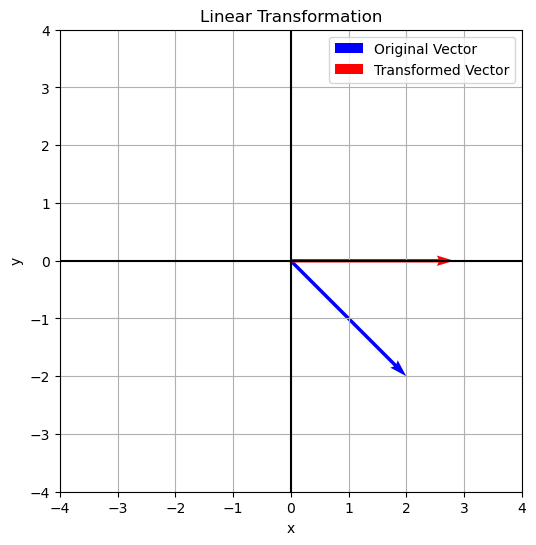

In [12]:
#2c 
#Visualize the Transformation
fig, ax = plt.subplots(figsize=(6,6))

#Original vector
ax.quiver(0,0,x[0],x[1],
          angles='xy',
          scale_units='xy',
          scale=1,
          color='blue',
          label='Original Vector')

#Transformed vector
ax.quiver(0,0,Tx[0],Tx[1],
          angles='xy',
          scale_units='xy',
          scale=1,
          color='red',
          label='Transformed Vector')

ax.set_xlim(-4,4)
ax.set_ylim(-4,4)

ax.set_xlabel("x")
ax.set_ylabel("y")

ax.grid(True)
ax.axhline(0,color='black')
ax.axvline(0,color='black')

ax.set_aspect('equal')

plt.legend()
plt.title("Linear Transformation")
plt.show()

#2c: The transformation rotates every vector 45° counter-clockwise around the origin. The length of each of the vectors remain unchanged because the transformation matrix is an orthogonal rotation matrix.

In [13]:
#3
#import 
import numpy as np

In [14]:
#create matrix a
A = np.array([
    [4, 0, 1],
    [-1, -6, -2],
    [5, 0, 0]
])

In [16]:
#3a 
#define the vector
v1 = np.array([2, 3, 1])

In [17]:
#compute Av
Av1 = A @ v1

print("A*v1 =")
print(Av1)

A*v1 =
[  9 -22  10]


In [18]:
#check if eigenvector
ratio = Av1 / v1

print("Ratios:")
print(ratio)

Ratios:
[ 4.5        -7.33333333 10.        ]


#a: No, because all ratios are not identical.

In [19]:
#3b 
v2 = np.array([0,1,0])

Av2 = A @ v2

print("A*v2 =")
print(Av2)

A*v2 =
[ 0 -6  0]


In [20]:
#check 
print(Av2)

[ 0 -6  0]


#b: No, because all ratios are not identical.

In [22]:
#3c 
#Find all eigenvalues and eigenvector values 
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print()

print("Eigenvectors:")
print(eigenvectors)

Eigenvalues:
[-6.  5. -1.]

Eigenvectors:
[[ 0.          0.69431384 -0.18493168]
 [ 1.         -0.18935832 -0.33287702]
 [ 0.          0.69431384  0.9246584 ]]


In [23]:
#3c 
#print values nicely 
for i in range(len(eigenvalues)):
    print(f"Eigenvalue {i+1}: {eigenvalues[i]}")
    print("Eigenvector:")
    print(eigenvectors[:,i])
    print()

Eigenvalue 1: -6.0
Eigenvector:
[0. 1. 0.]

Eigenvalue 2: 5.0
Eigenvector:
[ 0.69431384 -0.18935832  0.69431384]

Eigenvalue 3: -1.0
Eigenvector:
[-0.18493168 -0.33287702  0.9246584 ]



In [24]:
#4 PCA
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [26]:
#load data
games = pd.read_csv("vgsales-12-4-2019-short.csv")

In [27]:
games.head()

,Rank,Name,Genre,ESRB_Rating,Platform,Publisher,Developer,Critic_Score,User_Score,Total_Shipped,Global_Sales,NA_Sales,PAL_Sales,JP_Sales,Other_Sales,Year
0,1,Wii Sports,Sports,E,Wii,Nintendo,Nintendo EAD,7.7,NaN,82.86,NaN,NaN,NaN,NaN,NaN,2006.0
1,2,Super Mario Bros.,Platform,NaN,NES,Nintendo,Nintendo EAD,10.0,NaN,40.24,NaN,NaN,NaN,NaN,NaN,1985.0
2,3,Mario Kart Wii,Racing,E,Wii,Nintendo,Nintendo EAD,8.2,9.1,37.14,NaN,NaN,NaN,NaN,NaN,2008.0
3,4,PlayerUnknown's Battlegrounds,Shooter,NaN,PC,PUBG Corporation,PUBG Corporation,NaN,NaN,36.60,NaN,NaN,NaN,NaN,NaN,2017.0
4,5,Wii Sports Resort,Sports,E,Wii,Nintendo,Nintendo EAD,8.0,8.8,33.09,NaN,NaN,NaN,NaN,NaN,2009.0


In [28]:
print(games.columns)

Index(['Rank', 'Name', 'Genre', 'ESRB_Rating', 'Platform', 'Publisher',
       'Developer', 'Critic_Score', 'User_Score', 'Total_Shipped',
       'Global_Sales', 'NA_Sales', 'PAL_Sales', 'JP_Sales', 'Other_Sales',
       'Year'],
      dtype='object')


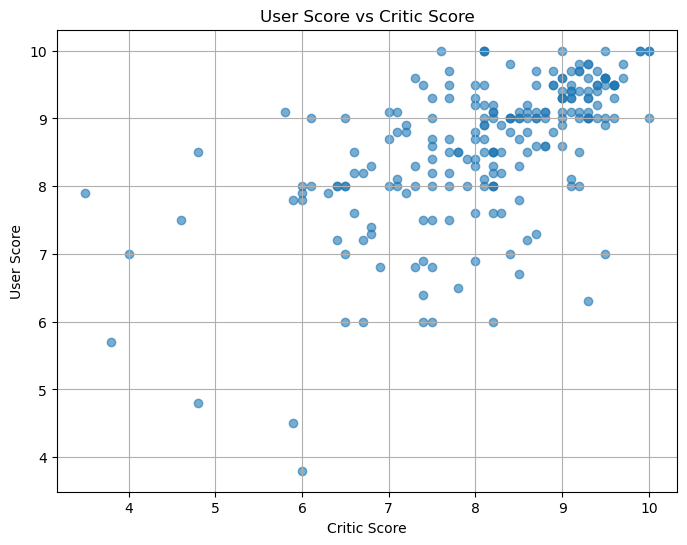

In [33]:
#a
#scatterplot
plt.figure(figsize=(8,6))

plt.scatter(
    games["Critic_Score"],
    games["User_Score"],
    alpha=0.6
)

plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("User Score vs Critic Score")

plt.grid(True)

plt.show()

In [36]:
#b
#PCA
X = games[["Critic_Score", "User_Score"]]

In [39]:
print(games.columns)

Index(['Rank', 'Name', 'Genre', 'ESRB_Rating', 'Platform', 'Publisher',
       'Developer', 'Critic_Score', 'User_Score', 'Total_Shipped',
       'Global_Sales', 'NA_Sales', 'PAL_Sales', 'JP_Sales', 'Other_Sales',
       'Year'],
      dtype='object')


In [50]:
games["Critic_Score"] = pd.to_numeric(games["Critic_Score"], errors="coerce")
games["User_Score"] = pd.to_numeric(games["User_Score"], errors="coerce")

In [51]:
#remove missing values 
X = games[["Critic_Score", "User_Score"]].dropna()

In [52]:
#check no other missing values left
print(X.isna().sum())

Critic_Score    0
User_Score      0
dtype: int64


In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [54]:
#calculate the center of the data
mean = X.mean()

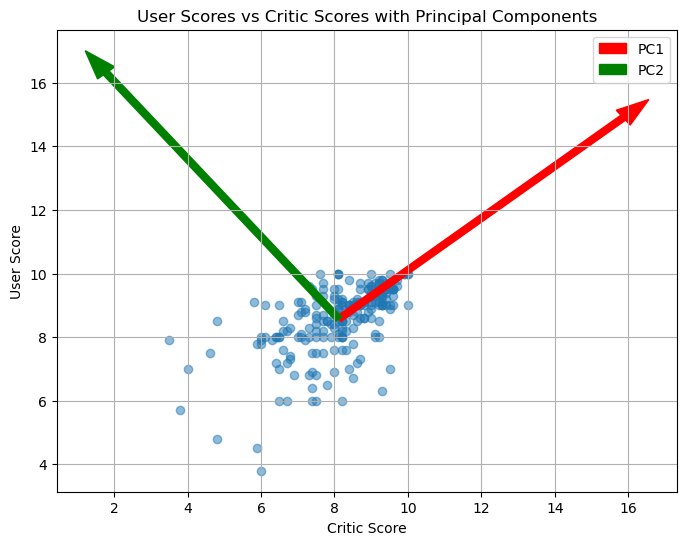

In [60]:
#4b
#draw principal components
plt.figure(figsize=(8,6))

#scatterplot
plt.scatter(
    X["Critic_Score"],
    X["User_Score"],
    alpha=0.5
)

#scale arrows so they are easier to see
scale = 10

#first principal component (red)
plt.arrow(
    mean["Critic_Score"],
    mean["User_Score"],
    pca.components_[0,0] * scale,
    pca.components_[0,1] * scale,
    color="red",
    width=0.2,
    label="PC1"
)

#second principal component (green)
plt.arrow(
    mean["Critic_Score"],
    mean["User_Score"],
    pca.components_[1,0] * scale,
    pca.components_[1,1] * scale,
    color="green",
    width=0.2,
    label="PC2"
)

plt.xlabel("Critic Score")
plt.ylabel("User Score")
plt.title("User Scores vs Critic Scores with Principal Components")

plt.legend()
plt.grid(True)

plt.show()